## Overview : - 
### Analyzing E-Commerce sales data to find meaningfull insights for business and by using present data perform prdective analysis.

## Start Importing libraries for statistical analysis

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as st
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
import mysql.connector
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy.stats import f_oneway

### Craeting connection from MYSQL database to access data from database

In [4]:
conn = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "Saleh@$0922",
    database = "Saleh_DB"
)

print("Connected Successfully")

Connected Successfully


### Instance of connection

In [5]:
cursor = conn.cursor()
cursor.execute("SHOW TABLES")

for table in cursor :
    print(table)

('ecommerce_sales',)
('flights_data',)
('sales_export',)


### After created connection write query to access tables from database

In [6]:
df = pd.read_sql("SELECT * FROM ecommerce_sales", conn)

### After accessing table print first five rows to see your table structure

In [7]:
df.head()

,order_id,order_data,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,23.176
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,60.520
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,39.664
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,63.232
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,40.336


### Check data types of each columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_data        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
 13  profit            50000 non-null  float64
dtypes: float64(5), int64(5), object(4)
memory usage: 5.3+ MB


### Check null values present or not in your table

In [9]:
df.isnull().sum()

order_id            0
order_data          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
profit              0
dtype: int64

### Describe your table usning describe() method for quick analysis and overview of your table like mean, std, count, and percentile percent

In [10]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue,profit
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475,32.866709
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968,26.311198
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000,0.192000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000,12.016000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000,25.270500
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000,48.448500
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000,124.978000


## See how many rows and columns are present in dataset

In [11]:
print(f"Total rows {df.shape[0]} and total columns {df.shape[1]}")

Total rows 50000 and total columns 14


### In table date presnt in object format so I need to convert them into date type

In [12]:
df.rename(columns={'order_data':'order_date'}, inplace=True)

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [14]:
df['year'] = df['order_date'].dt.year

In [15]:
df['month'] = df['order_date'].dt.month

In [16]:
df['day'] = df['order_date'].dt.day

In [17]:
df['day_name'] = df['order_date'].dt.day_name()

In [18]:
df['month_name'] = df['order_date'].dt.month_name()

In [19]:
df['discount_percent'] = df['discount_percent'].astype(int)

In [20]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit,year,month,day,day_name,month_name
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,23.176,2022,4,13,Wednesday,April
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,60.520,2023,3,12,Sunday,March
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,39.664,2022,9,28,Wednesday,September
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,63.232,2022,4,17,Sunday,April
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,40.336,2022,3,13,Sunday,March


In [21]:
df.rename(columns={'total_revenue':'net_revenue'}, inplace=True)

In [22]:
df['gross_revenue'] = df['price'] * df['quantity_sold']

### Creating KPI's

In [23]:
total_amount_before_discount = df['gross_revenue'].sum()
total_amount_after_discount = df['net_revenue'].sum()
total_discounted_amount = df['discounted_price'].sum()
total_profit = df['profit'].sum()
print(f"Total earning before discount : {total_amount_before_discount}")
print(f"Total earning after discount : {total_amount_after_discount}")
print(f"Total earning from discounted amount : {total_discounted_amount}")
print(f"Total profit : {total_profit}")


Total earning before discount : 37913104.54000001
Total earning after discount : 32866573.740000002
Total earning from discounted amount : 10944328.29
Total profit : 1643335.448


In [24]:
# Dsitribution percentage by product category
# Distribution percentage of quantity sold
# Distribution percentage by discount perecent
# Distribution percentage of ratings
# Distribution percentage of payment method
# Distribution percentage of review counts
# Distribution percentage by year
# Distribution percentage by month
# Distribution percentage by day
# Distribution percentage by customer region

columns = [
    'product_category',
    'quantity_sold',
    'discount_percent',
    'rating',
    'payment_method',
    'review_count',
    'year',
    'month_name',
    'day_name',
    'customer_region',
]

for col in columns :
    print(f"\nDistribution percentage of {col}")
    print((df[col].value_counts(normalize = True) * 100).round(2).astype(str) + '%')
    print("_" * 50)


Distribution percentage of product_category
product_category
Beauty            16.93%
Fashion           16.73%
Books             16.65%
Electronics       16.64%
Sports            16.53%
Home & Kitchen    16.52%
Name: proportion, dtype: object
__________________________________________________

Distribution percentage of quantity_sold
quantity_sold
1    20.12%
3    20.05%
5    20.01%
4    19.99%
2    19.83%
Name: proportion, dtype: object
__________________________________________________

Distribution percentage of discount_percent
discount_percent
5     16.99%
20    16.69%
30    16.67%
15    16.62%
10     16.6%
0     16.43%
Name: proportion, dtype: object
__________________________________________________

Distribution percentage of rating
rating
1.9    2.66%
4.2    2.66%
3.5    2.63%
1.5    2.61%
2.2    2.59%
2.8    2.58%
1.6    2.58%
3.7    2.56%
3.9    2.56%
4.5    2.55%
3.3    2.52%
1.2    2.52%
2.0    2.52%
1.7    2.51%
4.3    2.51%
2.1    2.51%
2.9    2.51%
1.8     2.5%
4.0    

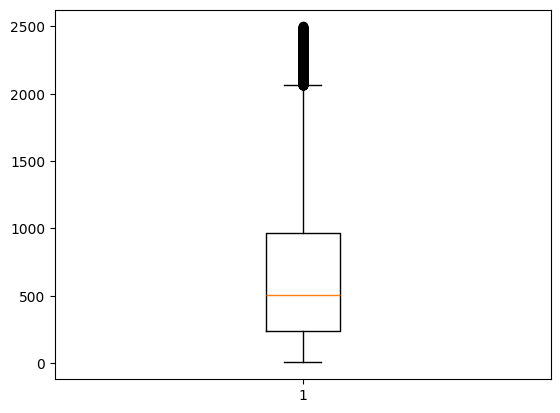

In [90]:
# Ploting outliers for gross revenue

plt.boxplot(df['net_revenue'])
plt.show()

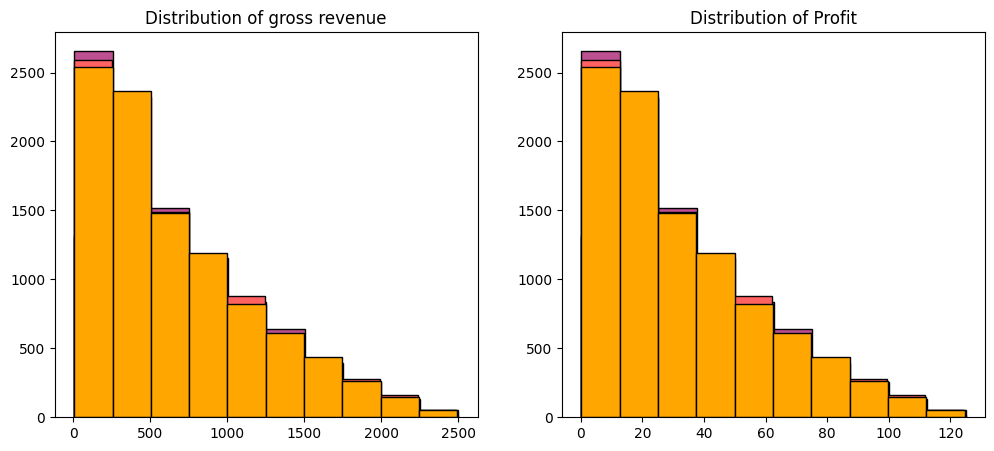

In [91]:
# Ploting distribution of gross revenue and profit

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Distribution of gross revenue")
plt.hist(df[df['payment_method']=='Wallet']['net_revenue'], histtype='barstacked', bins = 20, edgecolor = 'k', color ='#003f5c', label ='Wallet')
plt.hist(df[df['payment_method']=='UPI']['net_revenue'], histtype='barstacked', bins = 20, edgecolor = 'k', color = '#58508d', label ='UPI')
plt.hist(df[df['payment_method']=='Debit Card']['net_revenue'], histtype='barstacked', edgecolor='k', color='#bc5090', label='Debit Card')
plt.hist(df[df['payment_method']=='Cash on Delivery']['net_revenue'], histtype='barstacked', edgecolor='k', color='#ff6361', label='Cash on Delivery')
plt.hist(df[df['payment_method']=='Credit Card']['net_revenue'], histtype='barstacked', edgecolor='k', color='#ffa600', label='Credit Crad')

plt.subplot(1,2,2)
plt.title("Distribution of Profit")
plt.hist(df[df['payment_method']=='Wallet']['profit'], histtype='barstacked', bins = 20, edgecolor = 'k', color ='#003f5c', label ='Wallet')
plt.hist(df[df['payment_method']=='UPI']['profit'], histtype='barstacked', bins = 20, edgecolor = 'k', color = '#58508d', label ='UPI')
plt.hist(df[df['payment_method']=='Debit Card']['profit'], histtype='barstacked', edgecolor='k', color='#bc5090', label='Debit Card')
plt.hist(df[df['payment_method']=='Cash on Delivery']['profit'], histtype='barstacked', edgecolor='k', color='#ff6361', label='Cash on Delivery')
plt.hist(df[df['payment_method']=='Credit Card']['profit'], histtype='barstacked', edgecolor='k', color='#ffa600', label='Credit Crad')

plt.show()

In [92]:
df.groupby('payment_method').agg({'net_revenue':['mean','std'], 'profit':['mean','std']})

net_revenue                 profit           
                        mean         std       mean        std
payment_method                                                
Cash on Delivery  659.452699  526.695159  32.972773  26.334760
Credit Card       660.081465  526.142365  33.004206  26.307117
Debit Card        653.443516  523.110841  32.672310  26.155538
UPI               652.851899  524.527429  32.642730  26.226370
Wallet            660.858744  530.625024  33.043073  26.531254

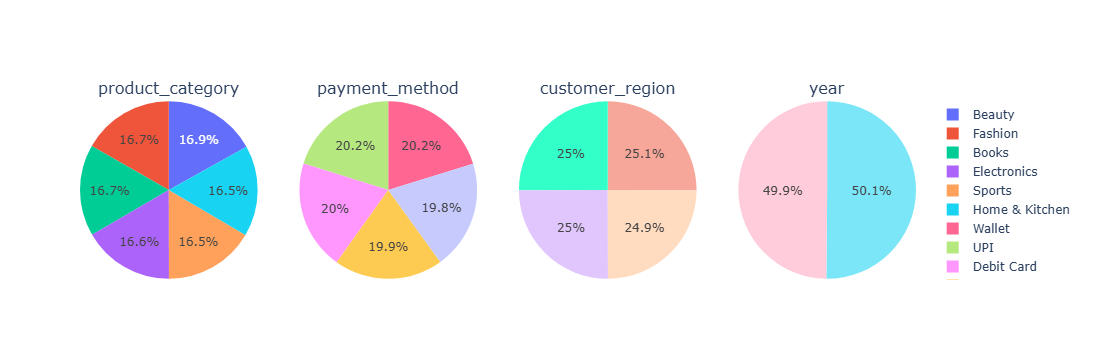

In [28]:
# Ploting subplot pie char to see contribution of each col present in cols var

cols = ['product_category', 'payment_method', 'customer_region', 'year']

fig = make_subplots(
    rows=1, cols=len(cols),
    specs=[[{'type': 'domain'}]*len(cols)],
    subplot_titles=cols
)

for i, col in enumerate(cols):
    vc = df[col].value_counts()
    fig.add_trace(
        go.Pie(labels=vc.index, values=vc.values),
        row=1, col=i+1
    )

fig.show()

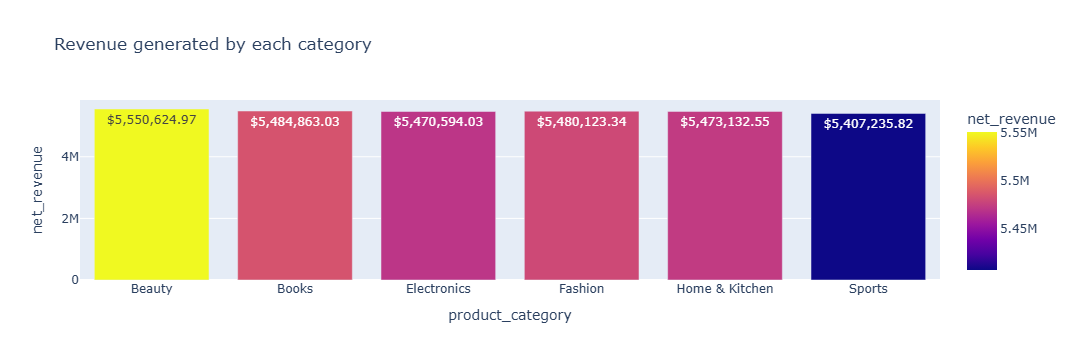

In [94]:
# Ploting bar chart to see revenue contribution by product category

vc = df.groupby('product_category')['net_revenue'].sum()

fig = px.bar(
    vc,
    y='net_revenue',
    text='net_revenue',
    title='Revenue generated by each category',
    color='net_revenue',
    color_continuous_scale='Plasma'
)
fig.update_traces(
    textposition='inside',
    texttemplate='$%{y:,.2f}'
)

fig.show()

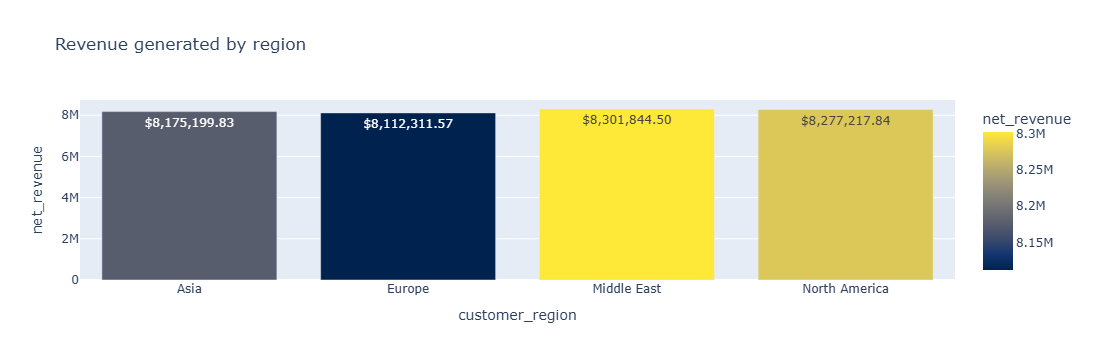

In [95]:
vc = df.groupby('customer_region')['net_revenue'].sum()

fig = px.bar(
    vc,
    y='net_revenue',
    text='net_revenue',
    title="Revenue generated by region",
    color='net_revenue',
    color_continuous_scale='Cividis'
)
fig.update_traces(
    textposition='inside',
    texttemplate='$%{y:,.2f}'
)
fig.show()

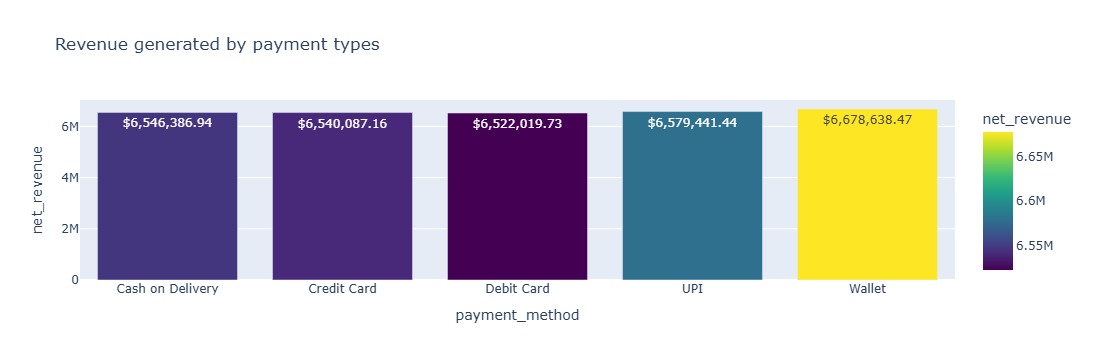

In [96]:
vc = df.groupby('payment_method')['net_revenue'].sum()

fig = px.bar(
    vc,
    y='net_revenue',
    text='net_revenue',
    title="Revenue generated by payment types",
    color='net_revenue',
    color_continuous_scale='Viridis'
)
fig.update_traces(
    textposition='inside',
    texttemplate='$%{y:,.2f}'
)
fig.show()

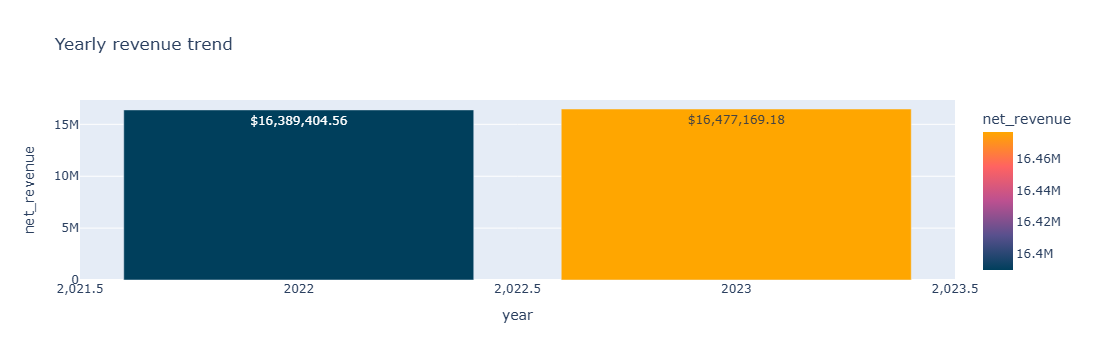

In [97]:
vc = df.groupby('year')['net_revenue'].sum()

fig = px.bar(
    vc,
    y='net_revenue',
    color='net_revenue',
    color_continuous_scale=[
        '#003f5c',
        '#58508d',
        '#bc5090',
        '#ff6361',
        '#ffa600'
    ],
    text='net_revenue',
    title="Yearly revenue trend"
)
fig.update_traces(
    texttemplate='$%{y:,.2f}',
    textposition='inside'
)
fig.show()


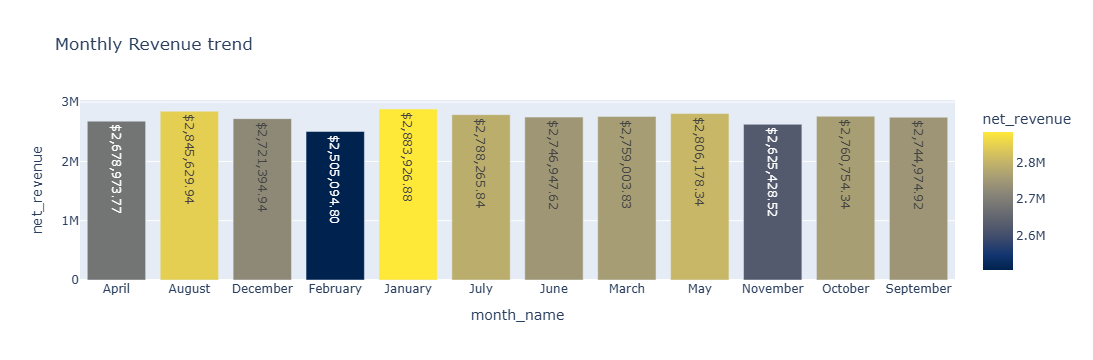

In [98]:
vc = df.groupby('month_name')['net_revenue'].sum()

fig = px.bar(
    vc,
    y='net_revenue',
    text='net_revenue',
    color_continuous_scale='Cividis',
    title="Monthly Revenue trend",
    color='net_revenue'
)
fig.update_traces(
    texttemplate='$%{y:,.2f}',
    textposition='inside'
)
fig.show()

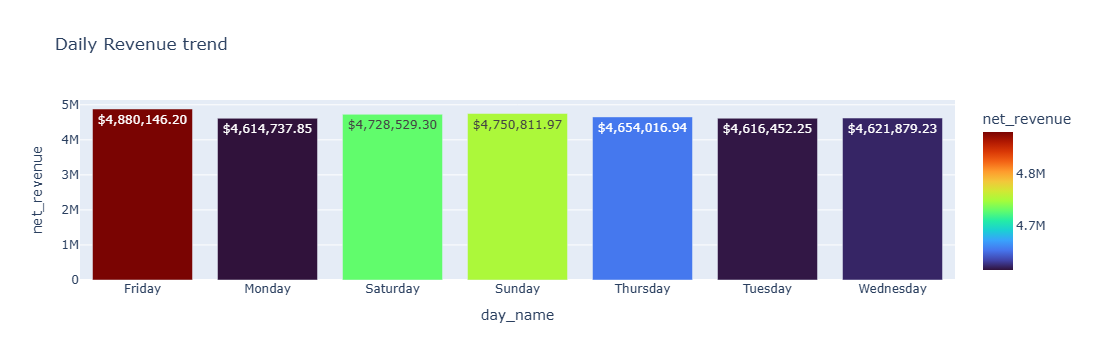

In [99]:
vc = df.groupby('day_name')['net_revenue'].sum()

fig = px.bar(
    vc,
    y='net_revenue',
    text='net_revenue',
    color_continuous_scale='Turbo',
    title="Daily Revenue trend",
    color='net_revenue'
)
fig.update_traces(
    texttemplate='$%{y:,.2f}',
    textposition='inside'
)
fig.show()


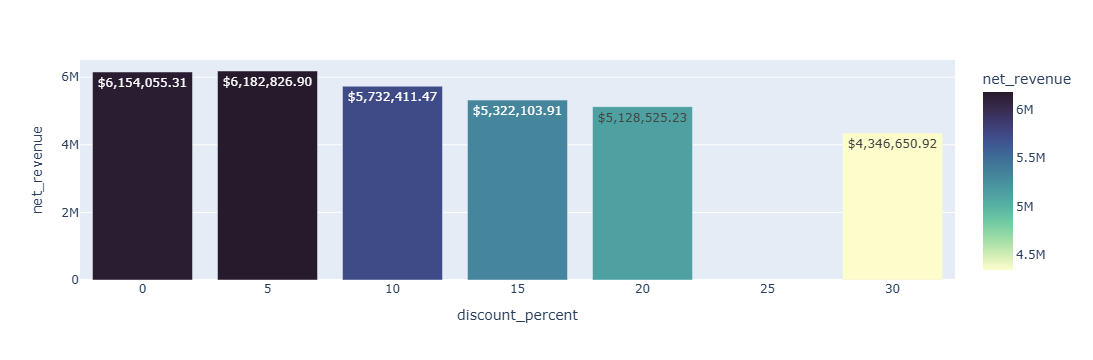

In [100]:
vc = df.groupby('discount_percent')['net_revenue'].sum()

fig = px.bar(
    vc,
    y='net_revenue',
    text='net_revenue',
    color='net_revenue',
    color_continuous_scale='deep'
)
fig.update_traces(
    texttemplate='$%{y:,.2f}',
    textposition='inside'
)
fig.show()

In [78]:
df['discount_percent'].value_counts()

discount_percent
5     8495
20    8344
30    8334
15    8310
10    8301
0     8216
Name: count, dtype: int64

In [83]:
# AVG profit by category

df.groupby('product_category')['profit'].mean()

product_category
Beauty            32.785868
Books             32.934347
Electronics       32.876302
Fashion           32.756403
Home & Kitchen    33.138500
Sports            32.711784
Name: profit, dtype: float64

In [113]:
# MAX profit per category

df.groupby('product_category')['profit'].max()

product_category
Beauty            124.943
Books             124.625
Electronics       124.615
Fashion           124.160
Home & Kitchen    124.690
Sports            124.978
Name: profit, dtype: float64

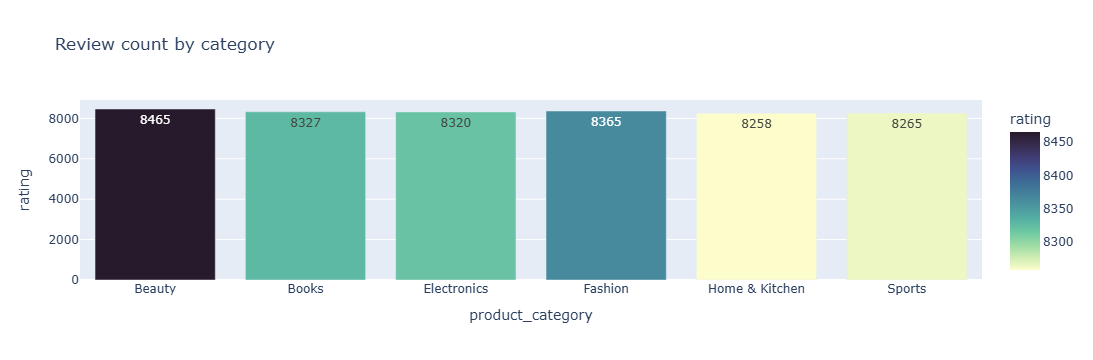

In [103]:
vc = df.groupby('product_category')['rating'].count()

fig = px.bar(
    vc,
    y='rating',
    text='rating',
    color='rating',
    color_continuous_scale='deep',
    title='Review count by category'
)
fig.update_traces(
    textposition='inside'
)
fig.show()
    

In [60]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,net_revenue,profit,year,month,day,day_name,month_name,gross_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,23.176,2022,4,13,Wednesday,April,515.00
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,60.520,2023,3,12,Sunday,March,1513.00
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,39.664,2022,9,28,Wednesday,September,991.60
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,63.232,2022,4,17,Sunday,April,1487.80
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,40.336,2022,3,13,Sunday,March,806.72


Check correlation between:
price vs quantity_sold
discount_percent vs profit
rating vs review_count
net_revenue vs profit

In [135]:
# Creating the copy of origianal data and extract only important columnn from data

df_copy = df

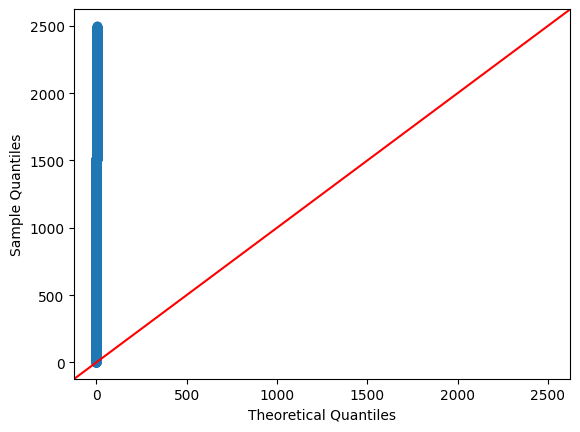

In [136]:
# Checking disttribution of net revenue are normal or not by using qqplot
# See the blue line goes traight doest not follow orange line means net revenue not normally distributed

sm.qqplot(df_copy['net_revenue'], line='45')
plt.show()

In [137]:
df_copy = df_copy[['product_category','price','discount_percent','quantity_sold','payment_method','rating','review_count','net_revenue',
           'gross_revenue']].copy()

In [138]:
df_copy

,product_category,price,discount_percent,quantity_sold,payment_method,rating,review_count,net_revenue,gross_revenue
0,Books,128.75,10,4,UPI,3.5,443,463.52,515.00
1,Fashion,302.60,20,5,Credit Card,3.7,475,1210.40,1513.00
2,Sports,495.80,20,2,UPI,4.4,183,793.28,991.60
3,Books,371.95,15,4,UPI,5.0,212,1264.64,1487.80
4,Beauty,201.68,0,4,UPI,4.6,308,806.72,806.72
...,...,...,...,...,...,...,...,...,...
49995,Beauty,26.99,0,5,Credit Card,2.4,386,134.95,134.95
49996,Beauty,294.23,10,5,Credit Card,3.1,8,1324.05,1471.15
49997,Electronics,352.11,30,4,Debit Card,3.1,104,985.92,1408.44
49998,Beauty,307.54,5,1,UPI,1.8,316,292.16,307.54


In [147]:
df_copy[['price','discount_percent','quantity_sold','rating','review_count','net_revenue','gross_revenue']].corr()

,price,discount_percent,quantity_sold,rating,review_count,net_revenue,gross_revenue
price,1.000000,-0.004654,0.004405,0.006386,0.001282,0.711094,0.722704
discount_percent,-0.004654,1.000000,0.001399,0.003715,0.005193,-0.144392,-0.003863
quantity_sold,0.004405,0.001399,1.000000,-0.002879,0.000717,0.594404,0.604887
rating,0.006386,0.003715,-0.002879,1.000000,-0.002895,0.001804,0.001983
review_count,0.001282,0.005193,0.000717,-0.002895,1.000000,0.002208,0.002683
net_revenue,0.711094,-0.144392,0.594404,0.001804,0.002208,1.000000,0.983846
gross_revenue,0.722704,-0.003863,0.604887,0.001983,0.002683,0.983846,1.000000


## Hypothesis testing
### 1. H₀ (Null Hypothesis): Payment method has no effect on sales (means are equal)
### 2. H₁ (Alternative Hypothesis): Payment method affects sales (at least one mean is different)

In [145]:
payment_type_group = df_copy.groupby('payment_method')['quantity_sold'].apply(list)

In [146]:
f_stat, p_value = f_oneway(*payment_type_group)
print("f_stat :", f_stat)
print("p_value :", p_value)

f_stat : 0.99366363628754
p_value : 0.4094575409933331


#### Statistical testing using ANOVA showed that payment methods do not significantly impact sales performance (p > 0.05). This indicates that customer purchase behavior is independent of payment choice.

In [148]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df['quantity_sold'],
    groups=df['payment_method'],
    alpha=0.05
)

print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1         group2   meandiff p-adj   lower  upper  reject
------------------------------------------------------------------
Cash on Delivery Credit Card   0.0052  0.999 -0.0497   0.06  False
Cash on Delivery  Debit Card  -0.0187 0.8847 -0.0734  0.036  False
Cash on Delivery         UPI  -0.0298 0.5691 -0.0844 0.0248  False
Cash on Delivery      Wallet  -0.0097 0.9889 -0.0642 0.0449  False
     Credit Card  Debit Card  -0.0239  0.758 -0.0786 0.0309  False
     Credit Card         UPI   -0.035 0.4049 -0.0896 0.0196  False
     Credit Card      Wallet  -0.0148 0.9467 -0.0694 0.0397  False
      Debit Card         UPI  -0.0111 0.9811 -0.0657 0.0434  False
      Debit Card      Wallet    0.009 0.9915 -0.0455 0.0635  False
             UPI      Wallet   0.0201 0.8505 -0.0342 0.0745  False
------------------------------------------------------------------


After performing ANOVA, I conducted a Tukey HSD post-hoc test to identify pairwise differences between payment methods. All adjusted p-values were greater than 0.05, and confidence intervals included zero, indicating no statistically significant differences between any payment method pairs. This confirms that payment method does not impact sales performance.

#### There is NO statistically significant difference between ANY payment methods.

### That means: COD ≈ UPI ≈ Card ≈ Wallet All behave almost the same in terms of sales

In [150]:
# Question:
# Does discount_percent affect quantity_sold?

from scipy.stats import pearsonr

corr, p_value = pearsonr(df_copy['discount_percent'], df_copy['quantity_sold'])
print("Correlation :", corr)
print("P-Value :", p_value)

Correlation : 0.0013989282759390054
P-Value : 0.7544309402255798


### Discount percent does NOT significantly affect sales (quantity_sold)

In [151]:
df_copy['discount_group'] = pd.cut(
    df_copy['discount_percent'],
    bins=[0,10,30,100],
    labels=['Low','Medium','High']
)

<Axes: xlabel='discount_group', ylabel='quantity_sold'>

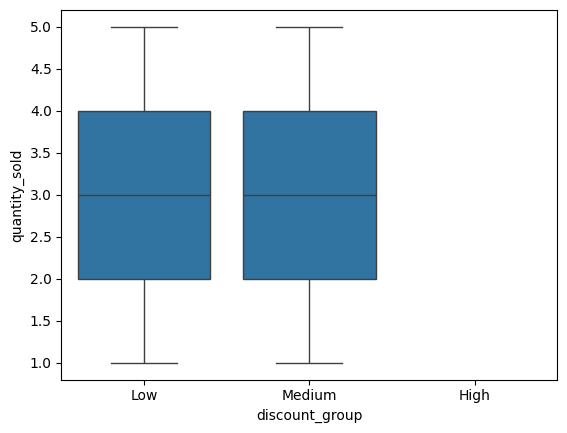

In [153]:
sns.boxplot(x='discount_group', y='quantity_sold', data=df_copy)

### All the dicount percent lay between low and medium the discount percent less then 30% no high discount present in sales

In [156]:
pearsonr(df_copy['discount_percent'], df['profit'])

PearsonRResult(statistic=np.float64(-0.14439204949878875), pvalue=np.float64(4.3928593173194096e-231))

### I performed Pearson correlation analysis and found a statistically significant relationship (p-value < 0.05). The correlation coefficient was -0.144, indicating a weak negative relationship. This suggests that as discount increases, the target variable slightly decreases, though the effect size is small.